In [1]:
%matplotlib widget

In [2]:
import logging
import os
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

from xasml import resource_path
from xasml.datasets.fdmnes import FE_REFERENCE_MBARN
from xasml.models.data import Processor
from xasml.models.io import read_from_h5
from xasml.models.metrics import calculate_accuracies, display_metrics

In [3]:
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
logging.getLogger("xasml").setLevel(logging.DEBUG)
logger = logging.getLogger("xasml.random_forest_classifier_augmented")

plt.style.use("stylelib/presentation.mplstyle")

In [4]:
# Define some constants.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

ELEMENT = "Fe"
JOB = "job15"
RESOURCE = "xasml:datasets/fdmnes/materials.h5"
ENERGY_SHIFT = 7112
ENERGY_MIN = -10 + ENERGY_SHIFT
ENERGY_MAX = 60 + ENERGY_SHIFT
LABELS = ["O:6", "T:4"]
NORMALIZATION = "area"  # Z-score fails when adding noise.
OUTLIER_THRESHOLD = 4
PREFIX = os.path.join("figures", "random_forest_classifier_augmented")
EXTENSION = "pdf"
DPI = 300

# Read data from file.
X, y, metas = read_from_h5(resource_path(RESOURCE), ELEMENT, JOB)

# Create a processor object.
processor = Processor(X, y, metas=metas)

## Baseline

2026-08-17 22:44:35,329 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:44:35,329 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:44:38,228 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:44:38,230 - xasml.models.data - DEBUG - Number of occurrences for each label:


2026-08-17 22:44:38,231 - xasml.models.data - DEBUG - O:6: 2027


...

2026-08-17 22:44:43,366 - xasml.models.metrics - INFO -   O:6: 96.6%


2026-08-17 22:44:43,366 - xasml.models.metrics - INFO -   T:4: 88.1%


2026-08-17 22:44:43,367 - xasml.models.metrics - INFO - Accuracy: 94.1%


2026-08-17 22:44:43,368 - xasml.models.metrics - INFO - F1 score: 94.1%


2026-08-17 22:44:43,537 - xasml.models.metrics - DEBUG - Confusion matrix saved to figures/random_forest_classifier_augmented_original_cm.pdf.


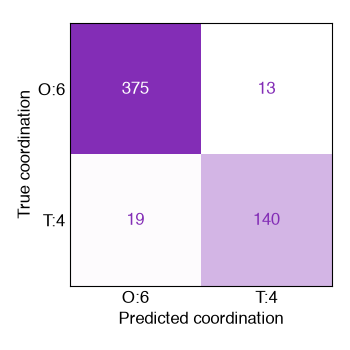

In [5]:
# Prepare the data and train the original (un-augmented) model.
processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
energies = energies[mask]
processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
processor.normalize(method=NORMALIZATION, reference=energies)
processor.split(test_size=0.20, random_seed=RANDOM_SEED)

model = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_SEED, class_weight="balanced"
)
model.fit(processor.X_train, processor.y_train)
y_pred = model.predict(processor.X_test)
calculate_accuracies(processor.y_test, y_pred)
display_metrics(
    processor.y_test,
    y_pred,
    display_labels=LABELS,
    cm_name=f"{PREFIX}_original_cm.{EXTENSION}",
    dpi=DPI,
)

# Save the model to a pickle file.
with open(f"{PREFIX}_model.pkl", "wb") as f:
    pickle.dump(model, f)

## Augmented Training

Enhance the training set by adding noisy copies of the spectra. The random forest
is fragile to statistical noise but tolerant of energy shifts and self-absorption,
so augmentation is focused on noise only, with a larger fraction and a slightly
lower SNR floor than the test range. The perturbed spectra are appended to the
training set.

In [6]:
# Prepare the data exactly as for the original model, then augment the
# training set with perturbed spectra.
processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
energies = energies[mask]
processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
processor.split(test_size=0.20, random_seed=RANDOM_SEED)

# Augment the training set with noisy copies of the spectra.
processor.augment(
    energies=energies,
    fraction=2 / 3,
    snr_range=(10, 250),
    noise_reference_intensity=FE_REFERENCE_MBARN,
    shift_range=None,
    normalization=NORMALIZATION,
    random_seed=RANDOM_SEED,
)
processor.normalize(
    method=NORMALIZATION, reference=energies, subset="test"
)

2026-08-17 22:44:43,566 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:44:43,567 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:44:46,607 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:44:46,609 - xasml.models.data - DEBUG - Number of occurrences for each label:


2026-08-17 22:44:46,609 - xasml.models.data - DEBUG - O:6: 2027


...

2026-08-17 22:44:49,654 - xasml.models.data - DEBUG - X_test: (547, 701)


2026-08-17 22:44:49,654 - xasml.models.data - DEBUG - y_test: (547,)


2026-08-17 22:44:49,655 - xasml.models.data - DEBUG - metas_test: 547


2026-08-17 22:44:49,714 - xasml.models.data - INFO - Augmented 'train' subset with 1458 samples (shift: 0, noise: 1458, self-absorption: 0). Total: 3645 samples.


2026-08-17 22:44:49,717 - xasml.models.data - INFO - Normalized the 'test' subset using the 'area' method.


2026-08-17 22:44:52,989 - xasml.models.metrics - INFO - Balanced accuracy: 93.1%


2026-08-17 22:44:52,989 - xasml.models.metrics - INFO -   O:6: 97.4%


2026-08-17 22:44:52,989 - xasml.models.metrics - INFO -   T:4: 88.7%


2026-08-17 22:44:52,990 - xasml.models.metrics - DEBUG - Evaluating predictions on 547 samples across 2 classes.


2026-08-17 22:44:52,992 - xasml.models.metrics - INFO - Balanced accuracy: 93.1%


...

2026-08-17 22:44:52,994 - xasml.models.metrics - INFO - Accuracy: 94.9%


2026-08-17 22:44:52,994 - xasml.models.metrics - INFO - F1 score: 94.8%


2026-08-17 22:44:53,055 - xasml.models.metrics - DEBUG - Confusion matrix saved to figures/random_forest_classifier_augmented_cm.pdf.


Augmented model - unperturbed test set:


{'accuracy': 0.9488117001828154,
 'balanced': 0.9305096284769501,
 np.str_('O:6'): 0.9742268041237113,
 np.str_('T:4'): 0.8867924528301887}

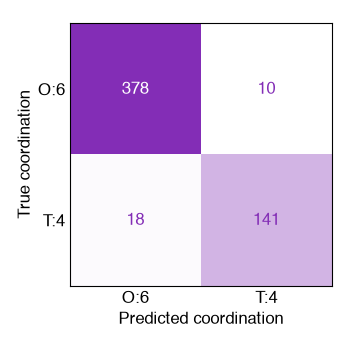

In [7]:
# Train the augmented model.
model_aug = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_SEED, class_weight="balanced"
)
model_aug.fit(processor.X_train, processor.y_train)

# Evaluate on the unperturbed test set.
y_pred_aug = model_aug.predict(processor.X_test)
print("Augmented model - unperturbed test set:")
calculate_accuracies(processor.y_test, y_pred_aug)
display_metrics(
    processor.y_test,
    y_pred_aug,
    display_labels=LABELS,
    cm_name=f"{PREFIX}_cm.{EXTENSION}",
    dpi=DPI,
)

### Comparison: original vs augmented model on perturbed test data

2026-08-17 22:44:53,085 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:44:53,085 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:44:56,971 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:44:56,972 - xasml.models.data - DEBUG - Number of occurrences for each label:


2026-08-17 22:44:56,973 - xasml.models.data - DEBUG - O:6: 2027


...

2026-08-17 22:45:24,796 - xasml.models.metrics - INFO -   T:4: 82.4%


2026-08-17 22:45:24,798 - xasml.models.metrics - INFO - Balanced accuracy: 89.1%


2026-08-17 22:45:24,798 - xasml.models.metrics - INFO -   O:6: 97.2%


2026-08-17 22:45:24,798 - xasml.models.metrics - INFO -   T:4: 81.1%


2026-08-17 22:45:24,798 - xasml.random_forest_classifier_augmented - INFO - Shift +1.0 eV, original: balanced=0.894 O:6=0.964 T:4=0.824; augmented: balanced=0.891 O:6=0.972 T:4=0.811


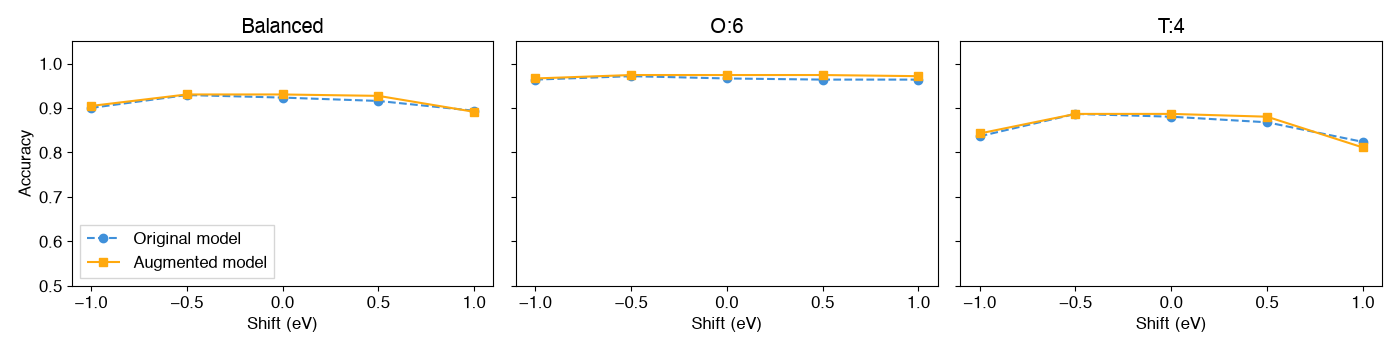

In [8]:
# --- Shift comparison ---
SHIFTS = [-1.0, -0.5, 0.0, 0.5, 1.0]
acc_orig_shift = []
acc_aug_shift = []
acc_orig_per_class = {label: [] for label in LABELS}
acc_aug_per_class = {label: [] for label in LABELS}

for shift in SHIFTS:
    processor.reset()
    processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

    energies = processor.metas[0]["energies"] + ENERGY_SHIFT
    processor.shift(shift, reference=energies)
    mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
    energies = energies[mask]
    processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
    processor.normalize(method=NORMALIZATION, reference=energies)
    processor.split(test_size=0.20, random_seed=RANDOM_SEED)

    y_pred_orig = model.predict(processor.X_test)
    y_pred_aug = model_aug.predict(processor.X_test)

    accs_orig = calculate_accuracies(processor.y_test, y_pred_orig)
    accs_aug = calculate_accuracies(processor.y_test, y_pred_aug)

    acc_orig_shift.append(accs_orig["balanced"])
    acc_aug_shift.append(accs_aug["balanced"])
    for label in LABELS:
        acc_orig_per_class[label].append(accs_orig[label])
        acc_aug_per_class[label].append(accs_aug[label])

    logger.info(
        f"Shift {shift:+.1f} eV, original: balanced={accs_orig['balanced']:.3f} "
        + " ".join(f"{label}={accs_orig[label]:.3f}" for label in LABELS)
        + f"; augmented: balanced={accs_aug['balanced']:.3f} "
        + " ".join(f"{label}={accs_aug[label]:.3f}" for label in LABELS)
    )

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)

# Balanced accuracy.
axes[0].plot(SHIFTS, acc_orig_shift, marker="o", ls="--", label="Original model")
axes[0].plot(SHIFTS, acc_aug_shift, marker="s", ls="-", label="Augmented model")
axes[0].set_title("Balanced")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Per-class accuracy.
for i, label in enumerate(LABELS):
    axes[i + 1].plot(
        SHIFTS, acc_orig_per_class[label], marker="o", ls="--", label="Original model"
    )
    axes[i + 1].plot(
        SHIFTS, acc_aug_per_class[label], marker="s", ls="-", label="Augmented model"
    )
    axes[i + 1].set_title(label)

for ax in axes:
    ax.set_xlabel("Shift (eV)")
    ax.set_ylim(0.5, 1.05)

fig.tight_layout()
fig.savefig(f"{PREFIX}_shift_comparison.{EXTENSION}", dpi=DPI)

2026-08-17 22:45:24,965 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:45:24,965 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:45:28,665 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:45:28,666 - xasml.models.data - DEBUG - Number of occurrences for each label:


2026-08-17 22:45:28,667 - xasml.models.data - DEBUG - O:6: 2027


...

2026-08-17 22:45:56,445 - xasml.models.metrics - INFO -   T:4: 88.1%


2026-08-17 22:45:56,447 - xasml.models.metrics - INFO - Balanced accuracy: 93.3%


2026-08-17 22:45:56,447 - xasml.models.metrics - INFO -   O:6: 97.9%


2026-08-17 22:45:56,448 - xasml.models.metrics - INFO -   T:4: 88.7%


2026-08-17 22:45:56,448 - xasml.random_forest_classifier_augmented - INFO - SNR 250, original: balanced=0.926 O:6=0.972 T:4=0.881; augmented: balanced=0.933 O:6=0.979 T:4=0.887


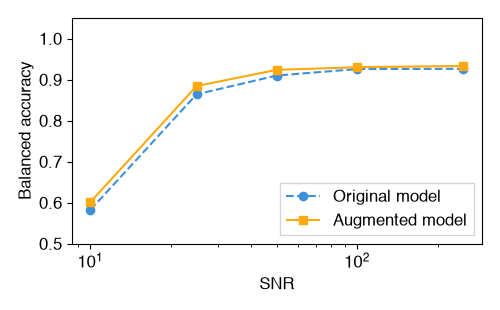

In [9]:
# --- Noise comparison ---
SNRS = [10, 25, 50, 100, 250]
acc_orig_noise = []
acc_aug_noise = []

for snr in SNRS:
    processor.reset()
    processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

    energies = processor.metas[0]["energies"] + ENERGY_SHIFT
    mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
    energies = energies[mask]
    processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
    processor.split(test_size=0.20, random_seed=RANDOM_SEED)
    processor.add_poisson_noise(
        snr=snr,
        reference_intensity=FE_REFERENCE_MBARN,
        normalization=NORMALIZATION,
        reference=energies,
        subset="test",
        random_seed=RANDOM_SEED,
    )

    y_pred_orig = model.predict(processor.X_test)
    y_pred_aug = model_aug.predict(processor.X_test)

    accs_orig = calculate_accuracies(processor.y_test, y_pred_orig)
    accs_aug = calculate_accuracies(processor.y_test, y_pred_aug)
    acc_orig_noise.append(accs_orig["balanced"])
    acc_aug_noise.append(accs_aug["balanced"])

    logger.info(
        f"SNR {snr}, original: balanced={accs_orig['balanced']:.3f} "
        + " ".join(f"{label}={accs_orig[label]:.3f}" for label in LABELS)
        + f"; augmented: balanced={accs_aug['balanced']:.3f} "
        + " ".join(f"{label}={accs_aug[label]:.3f}" for label in LABELS)
    )

fig, ax = plt.subplots(figsize=(5, 3.1))
ax.plot(SNRS, acc_orig_noise, marker="o", ls="--", label="Original model")
ax.plot(SNRS, acc_aug_noise, marker="s", ls="-", label="Augmented model")
ax.set_xscale("log")
ax.set_xlabel("SNR")
ax.set_ylabel("Balanced accuracy")
ax.legend()
ax.set_ylim(0.5, 1.05)
fig.tight_layout()
fig.savefig(f"{PREFIX}_noise_comparison.{EXTENSION}", dpi=DPI)

2026-08-17 22:45:56,696 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:45:56,696 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:46:00,478 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:46:00,479 - xasml.models.data - DEBUG - Number of occurrences for each label:


2026-08-17 22:46:00,479 - xasml.models.data - DEBUG - O:6: 2027


...

2026-08-17 22:46:03,675 - xasml.models.metrics - INFO -   T:4: 91.8%


2026-08-17 22:46:03,677 - xasml.models.metrics - INFO - Accuracy: 88.3%


2026-08-17 22:46:03,677 - xasml.models.metrics - INFO - F1 score: 88.6%


Original model - self-absorption test:

Augmented model - self-absorption test:


{'accuracy': 0.8829981718464351,
 'balanced': 0.8933978473708098,
 np.str_('O:6'): 0.8685567010309279,
 np.str_('T:4'): 0.9182389937106918}

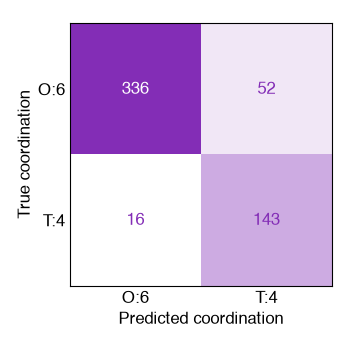

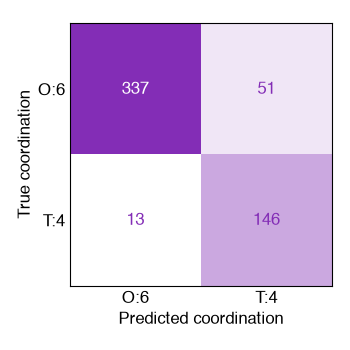

In [10]:
# --- Self-absorption comparison ---
processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
energies = energies[mask]
processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
processor.split(test_size=0.20, random_seed=RANDOM_SEED)

processor.add_incident_beam_self_absorption(
    subset="test",
    energies=energies,
    binder="boron nitride",
    phi=45,
    theta=45,
    absorbing_element=ELEMENT,
    compound_weight_fraction=0.1,
    thickness=0.1,
)
processor.normalize(method=NORMALIZATION, reference=energies, subset="test")

y_pred_orig = model.predict(processor.X_test)
y_pred_aug = model_aug.predict(processor.X_test)

print("Original model - self-absorption test:")
display_metrics(processor.y_test, y_pred_orig, display_labels=LABELS)
print("\nAugmented model - self-absorption test:")
display_metrics(processor.y_test, y_pred_aug, display_labels=LABELS)